In [34]:
import numpy as np
import pandas as pd
import sqlalchemy as db
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from src.get_all_data import get_all_data
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib

In [35]:
engine = db.create_engine('sqlite:///../data/raw/data.db')
df = get_all_data(engine)

Searching for events

[+] US Federal Funds Rate
Skipped — next release on 2026-07-29 (not yet passed)

[+] US FOMC Statement
Skipped — next release on 2026-07-29 (not yet passed)

[+] US FOMC Press Conference
Skipped — next release on 2026-07-29 (not yet passed)

[+] US FOMC Economic Projections
Skipped — next release on 2026-09-16 (not yet passed)

[+] US Core CPI m/m
Skipped — next release on 2026-08-12 (not yet passed)

[+] US CPI m/m
Skipped — next release on 2026-08-12 (not yet passed)

[+] US CPI y/y
Skipped — next release on 2026-08-12 (not yet passed)

[+] US PPI m/m
Skipped — next release on 2026-08-13 (not yet passed)

[+] US Core PCE Price Index m/m
Skipped — next release on 2026-07-30 (not yet passed)

[+] US Non-Farm Employment Change
Skipped — next release on 2026-08-07 (not yet passed)

[+] US Unemployment Rate
Skipped — next release on 2026-08-07 (not yet passed)

[+] US Average Hourly Earnings m/m
Skipped — next release on 2026-08-07 (not yet passed)

[+] US Advance GD

C:\Users\usuario\Desktop\Python\Market Regime\data\interim\process_db.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['EMA_14'] = ta.EMA(close, timeperiod=14)
C:\Users\usuario\Desktop\Python\Market Regime\data\interim\process_db.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['EMA_30'] = ta.EMA(close, timeperiod=30)
C:\Users\usuario\Desktop\Python\Market Regime\data\interim\process_db.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

All done


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4854 entries, 2007-03-29 to 2026-07-20
Columns: 167 entries, spy_open to US FOMC Statement
dtypes: float64(167)
memory usage: 6.2 MB


In [37]:
df.columns.tolist()

['spy_open',
 'spy_high',
 'spy_low',
 'spy_close',
 'spy_volume',
 'spy_EMA_14',
 'spy_EMA_30',
 'spy_EMA_60',
 'spy_SMA_14',
 'spy_SMA_30',
 'spy_SMA_60',
 'spy_BB_upper',
 'spy_BB_middle',
 'spy_BB_lower',
 'spy_RSI_14',
 'spy_RSI_21',
 'spy_RSI_30',
 'spy_MACD',
 'spy_MACD_signal',
 'spy_MACD_hist',
 'spy_AROON_down',
 'spy_AROON_up',
 'spy_MFI',
 'spy_AVGPRICE',
 'spy_MEDPRICE',
 'qqq_open',
 'qqq_high',
 'qqq_low',
 'qqq_close',
 'qqq_volume',
 'qqq_EMA_14',
 'qqq_EMA_30',
 'qqq_EMA_60',
 'qqq_SMA_14',
 'qqq_SMA_30',
 'qqq_SMA_60',
 'qqq_BB_upper',
 'qqq_BB_middle',
 'qqq_BB_lower',
 'qqq_RSI_14',
 'qqq_RSI_21',
 'qqq_RSI_30',
 'qqq_MACD',
 'qqq_MACD_signal',
 'qqq_MACD_hist',
 'qqq_AROON_down',
 'qqq_AROON_up',
 'qqq_MFI',
 'qqq_AVGPRICE',
 'qqq_MEDPRICE',
 '^vix_open',
 '^vix_high',
 '^vix_low',
 '^vix_close',
 '^vix_volume',
 '^vix_EMA_14',
 '^vix_EMA_30',
 '^vix_EMA_60',
 '^vix_SMA_14',
 '^vix_SMA_30',
 '^vix_SMA_60',
 '^vix_BB_upper',
 '^vix_BB_middle',
 '^vix_BB_lower',
 '^

In [38]:
df.head()

,spy_open,spy_high,spy_low,spy_close,spy_volume,spy_EMA_14,spy_EMA_30,spy_EMA_60,spy_SMA_14,spy_SMA_30,...,CPIAUCSL,T5YIE,T10YIE,ICSA,WALCL,M2SL,TEDRATE,US FOMC Economic Projections,US FOMC Press Conference,US FOMC Statement
date,,,,,,,,,,,,,,,,,,,,,
2007-03-29,100.615065,100.664481,99.662143,100.212723,139432700.0,100.001746,99.905028,99.687977,99.588258,99.853327,...,205.288,2.53,2.46,303000.0,863067.0,7134.3,0.44,1490.0,1490.0,41.0
2007-03-30,100.403285,100.826802,99.217414,100.233871,128194100.0,100.032696,99.926244,99.705875,99.667267,99.777470,...,205.288,2.51,2.44,303000.0,863067.0,7134.3,0.45,1489.0,1489.0,40.0
2007-04-02,100.346802,100.558566,99.866803,100.346802,79416400.0,100.074577,99.953377,99.726889,99.891945,99.707018,...,205.288,2.50,2.44,303000.0,863067.0,7168.2,0.44,1486.0,1486.0,37.0
2007-04-03,100.918521,101.631448,100.876171,101.426750,82417800.0,100.254867,100.048433,99.782622,100.142038,99.665299,...,205.288,2.47,2.42,303000.0,863067.0,7168.2,0.44,1485.0,1485.0,36.0
2007-04-04,101.426784,101.610307,101.052673,101.539726,63995200.0,100.426181,100.144646,99.840232,100.390659,99.628752,...,205.288,2.49,2.43,303000.0,869803.0,7168.2,0.43,1484.0,1484.0,35.0


In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [40]:
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [41]:
from itertools import product
def make_prior_from_durations(durations_days: list[float], n_states: int, alpha_off: float = 1.0) -> np.ndarray:

    prior = np.full((n_states, n_states), alpha_off)
    for i, duration in enumerate(durations_days):
        # p_ii = (D-1)/D → alpha_diag = (D-1)*(n-1)*alpha_off
        prior[i, i] = (duration - 1) * (n_states - 1) * alpha_off
    return prior

def score_durations(X, durations, n_states, n_iter=500):
    prior = make_prior_from_durations(durations, n_states)
    m = GaussianHMM(n_components=n_states, transmat_prior=prior,
                    covariance_type="diag", n_iter=n_iter, random_state=42)
    m.fit(X)
    return m.score(X), m

candidates = [
    [10, 30, 60, 120, 252],   # market cicles clasical modes
    [5,  20, 45,  90, 180],
    [15, 30, 60,  90, 252],
    [20, 60, 90, 180, 360],
    [30, 45, 60, 90, 120],
    [15, 30, 60, 90, 360],

    # --- Nuevas opciones ---
    [5,  10, 20,  50, 200],   # Clásico puro de medias móviles (semana, quincena, mes, 50 y 200 días)
    [8,  13, 21,  55, 233],   # Secuencia exacta de Fibonacci (muy usada en trading algorítmico)
    [7,  14, 28,  56, 112],   # Ciclos semanales exactos basados en días naturales (multiplos de 7)
    [21, 42, 63, 126, 252],   # Múltiplos exactos del mes comercial de 21 días hábiles (1, 2, 3, 6 meses y 1 año)
    [10, 20, 50, 100, 200],   # Modos redondos estándar de soportes/resistencias dinámicas
    [12, 26, 50, 100, 200],   # Combinación estilo MACD (12, 26) expandida a largo plazo
    [5,  21, 63, 126, 252],   # Periodos de ejecución institucional (1 semana, 1 mes, 1 trimestre, 1 semestre, 1 año)
    [9,  18, 36,  72, 144],   # Geometría del mercado / Ciclos de Gann (múltiplos y divisiones del círculo)
    [15, 45, 90, 180, 270],   # Trimestres de días naturales (3 meses, 6 meses, 9 meses)
    [20, 40, 80, 160, 320],   # Progresión geométrica basada en el mes institucional estándar
    [3,   5,  8,  13,  21],   # Micro-ciclos de alta frecuencia (Fibonacci para temporalidades cortas)
    [10, 25, 50,  75, 100],   # Cuartiles porcentuales aplicados a días de trading
    [22, 44, 66, 132, 264],   # Variante europea con promedio de 22 días hábiles por mes
    [5,  15, 30,  60, 180],   # Escala de aceleración rápida a mediano plazo
    [30, 60, 120, 240, 480],  # Ciclos macro extendidos a dos años de mercado
    [14, 28, 42,  84, 168],   # Ciclos basados en el indicador RSI estándar (14) y sus múltiplos
    [20, 50, 100, 150, 250],  # Variación de números redondos con el cierre de año ajustado a 250
    [8,  20, 50, 100, 200],   # Variante híbrida: micro-tendencia rápida (8) acoplada a niveles institucionales
    [10, 40, 80, 120, 240],   # Estructura cuatrimestral clásica limpia
    [5,  22, 65, 130, 260],   # Ajuste estricto considerando festivos variables en el año (260 días habituales)
]


n_states = 5

results = []
for durations in candidates:
    ll, m = score_durations(X_pca, durations, n_states=5)
    results.append((ll, durations, m))
    print(f"LL={ll:.2f} | durations={durations}")

best_ll, best_durations, best_model = max(results, key=lambda x: x[0])
print(f"\nBest durations: {best_durations}")
durations = best_durations

prior_matrix = make_prior_from_durations(durations, n_states)

for i in range(n_states):
    p_ii = prior_matrix[i, i] / prior_matrix[i].sum()
    print(f"  State {i}: {1/(1-p_ii):.1f} days")


print("Prior matrix:")
print(prior_matrix)

LL=-173789.13 | durations=[10, 30, 60, 120, 252]
LL=-173784.85 | durations=[5, 20, 45, 90, 180]
LL=-173784.71 | durations=[15, 30, 60, 90, 252]
LL=-173799.71 | durations=[20, 60, 90, 180, 360]
LL=-173784.08 | durations=[30, 45, 60, 90, 120]
LL=-173785.30 | durations=[15, 30, 60, 90, 360]
LL=-172989.94 | durations=[5, 10, 20, 50, 200]
LL=-173674.56 | durations=[8, 13, 21, 55, 233]
LL=-173779.73 | durations=[7, 14, 28, 56, 112]
LL=-173790.26 | durations=[21, 42, 63, 126, 252]
LL=-173785.80 | durations=[10, 20, 50, 100, 200]
LL=-173785.66 | durations=[12, 26, 50, 100, 200]
LL=-173789.98 | durations=[5, 21, 63, 126, 252]
LL=-173782.06 | durations=[9, 18, 36, 72, 144]
LL=-173798.97 | durations=[15, 45, 90, 180, 270]
LL=-173796.02 | durations=[20, 40, 80, 160, 320]
LL=-173773.86 | durations=[3, 5, 8, 13, 21]
LL=-173781.61 | durations=[10, 25, 50, 75, 100]
LL=-173791.31 | durations=[22, 44, 66, 132, 264]
LL=-173674.71 | durations=[5, 15, 30, 60, 180]
LL=-173809.64 | durations=[30, 60, 120, 24

In [42]:

prior_matrix = make_prior_from_durations(
    durations_days=durations,
    n_states=n_states,
    alpha_off=5.0
)

model = GaussianHMM(
    n_components=n_states,
    transmat_prior=prior_matrix,
    n_iter=2000,
    covariance_type="diag",
    random_state=42,

    tol=1e-4,
)
model.init_params = "smc"
model.fit(X_pca)

print(f"Converged: {model.monitor_.converged}")
print(f"Log-likelihood: {model.score(X_pca):.2f}")

# learned durations
for i in range(n_states):
    p_ii = model.transmat_[i, i]
    print(f"  State {i}: {1/(1-p_ii+1e-9):.1f} days (p_ii={p_ii:.3f})")

Converged: True
Log-likelihood: -173721.56
  State 0: 33.9 days (p_ii=0.970)
  State 1: 28.2 days (p_ii=0.965)
  State 2: 35.6 days (p_ii=0.972)
  State 3: 16.1 days (p_ii=0.938)
  State 4: 229.2 days (p_ii=0.996)


In [43]:
#save the featured cols for
joblib.dump(list(df.columns), '../models/feature_cols.pkl')

['../models/feature_cols.pkl']

In [44]:
states = model.predict(X_pca)
df['state'] = states

In [45]:
df.head()

,spy_open,spy_high,spy_low,spy_close,spy_volume,spy_EMA_14,spy_EMA_30,spy_EMA_60,spy_SMA_14,spy_SMA_30,...,T5YIE,T10YIE,ICSA,WALCL,M2SL,TEDRATE,US FOMC Economic Projections,US FOMC Press Conference,US FOMC Statement,state
date,,,,,,,,,,,,,,,,,,,,,
2007-03-29,100.615065,100.664481,99.662143,100.212723,139432700.0,100.001746,99.905028,99.687977,99.588258,99.853327,...,2.53,2.46,303000.0,863067.0,7134.3,0.44,1490.0,1490.0,41.0,0
2007-03-30,100.403285,100.826802,99.217414,100.233871,128194100.0,100.032696,99.926244,99.705875,99.667267,99.777470,...,2.51,2.44,303000.0,863067.0,7134.3,0.45,1489.0,1489.0,40.0,0
2007-04-02,100.346802,100.558566,99.866803,100.346802,79416400.0,100.074577,99.953377,99.726889,99.891945,99.707018,...,2.50,2.44,303000.0,863067.0,7168.2,0.44,1486.0,1486.0,37.0,0
2007-04-03,100.918521,101.631448,100.876171,101.426750,82417800.0,100.254867,100.048433,99.782622,100.142038,99.665299,...,2.47,2.42,303000.0,863067.0,7168.2,0.44,1485.0,1485.0,36.0,0
2007-04-04,101.426784,101.610307,101.052673,101.539726,63995200.0,100.426181,100.144646,99.840232,100.390659,99.628752,...,2.49,2.43,303000.0,869803.0,7168.2,0.43,1484.0,1484.0,35.0,0


In [46]:
df.tail()

,spy_open,spy_high,spy_low,spy_close,spy_volume,spy_EMA_14,spy_EMA_30,spy_EMA_60,spy_SMA_14,spy_SMA_30,...,T5YIE,T10YIE,ICSA,WALCL,M2SL,TEDRATE,US FOMC Economic Projections,US FOMC Press Conference,US FOMC Statement,state
date,,,,,,,,,,,,,,,,,,,,,
2026-07-14,750.909973,753.340027,748.659973,751.830017,35143100.0,747.224170,743.316966,732.884363,744.777867,744.671617,...,2.28,2.25,216000.0,6724564.0,23052.3,0.09,64.0,15.0,15.0,4
2026-07-15,754.239990,755.580017,750.200012,754.809998,43844800.0,748.235614,744.058452,733.603236,746.318582,744.547284,...,2.25,2.23,216000.0,6735609.0,23052.3,0.09,63.0,14.0,14.0,4
2026-07-16,752.760010,754.570007,747.880005,750.719971,46409800.0,748.566861,744.488228,734.164441,747.491438,744.252283,...,2.24,2.22,208000.0,6735609.0,23052.3,0.09,62.0,13.0,13.0,4
2026-07-17,742.080017,747.289978,740.799988,743.289978,62569200.0,747.863277,744.410921,734.463638,748.512865,743.887282,...,2.27,2.24,208000.0,6735609.0,23052.3,0.09,61.0,12.0,12.0,4
2026-07-20,747.059998,748.729980,742.250000,742.562500,28790022.0,747.156507,744.291668,734.729175,748.624472,743.403031,...,2.27,2.24,208000.0,6735609.0,23052.3,0.09,58.0,9.0,9.0,4


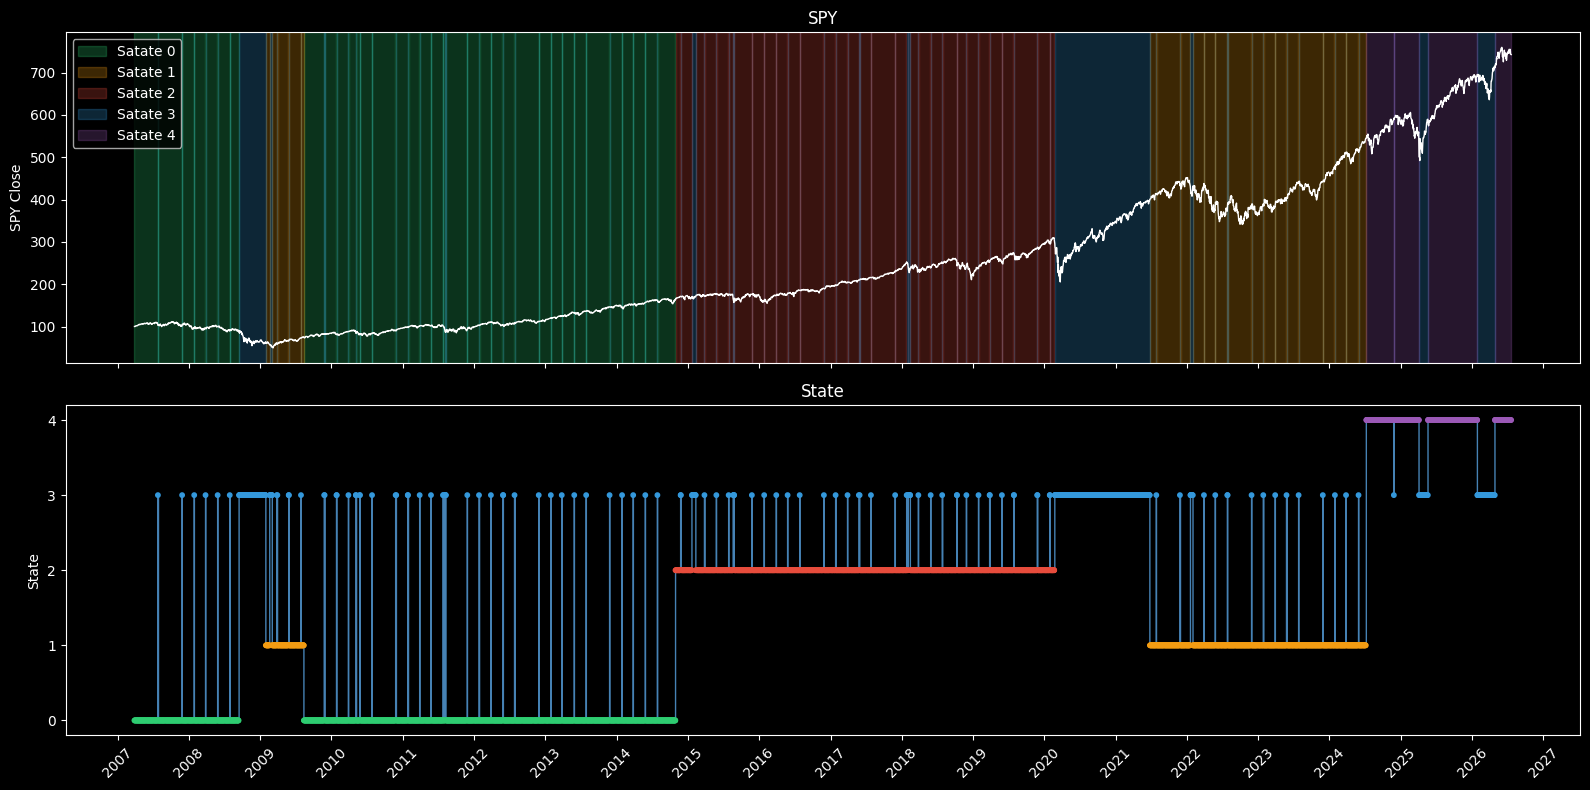

In [47]:
plt.style.use("dark_background")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

n_states = model.n_components
colors = colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db', '#9b59b6', '#e84393'][:n_states]

# ── SPY price ───────────────────────────────────────────────────────────────
ax1.plot(df.index, df['spy_close'], color='white', lw=1)
ax1.set_ylabel('SPY Close')
ax1.set_title('SPY')

for regime_id, color in enumerate(colors):
    mask = df['state'] == regime_id
    ax1.fill_between(df.index, 0, 1,
                     where=mask, alpha=0.25, color=color,
                     transform=ax1.get_xaxis_transform(),
                     label=f'Satate {regime_id}')
ax1.legend(loc='upper left')

# ── Estate ────────────────────────────────────────────────────────
ax2.plot(df.index, df['state'], color='steelblue', lw=1, drawstyle='steps-post')
ax2.scatter(df.index, df['state'],
            c=[colors[s] for s in df['state']], s=10, zorder=3)
ax2.set_yticks(range(n_states))
ax2.set_ylabel('State')
ax2.set_title('State')

ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

#save the img

plt.savefig('regimes.png', dpi=300, bbox_inches='tight')


plt.tight_layout()
plt.show()

In [48]:
#save model, scaler and pca
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(pca, '../models/pca.pkl')
joblib.dump(model, '../models/hmm_model.pkl')

['../models/hmm_model.pkl']

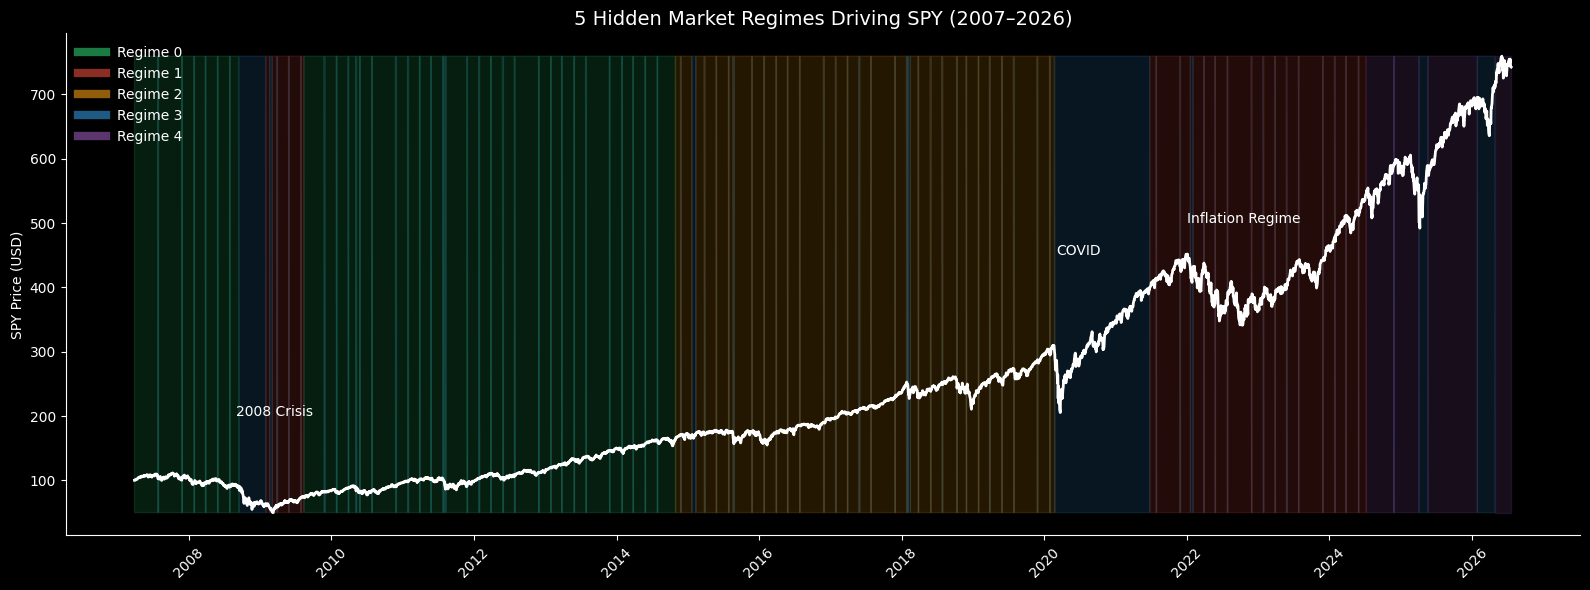

In [49]:
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(16, 6))

n_states = model.n_components

colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#9b59b6', '#e84393'][:n_states]

# ── SPY price ─────────────────────────────────────────────────────
ax.plot(df.index, df['spy_close'], color='white', lw=2)

ax.set_ylabel('SPY Price (USD)')
ax.set_title('5 Hidden Market Regimes Driving SPY (2007–2026)', fontsize=14)

# ── Regimes as background ─────────────────────────────────────────
for regime_id, color in enumerate(colors):
    mask = df['state'] == regime_id

    ax.fill_between(
        df.index,
        df['spy_close'].min(),
        df['spy_close'].max(),
        where=mask,
        color=color,
        alpha=0.15,
        interpolate=True
    )

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

handles = [
    plt.Line2D([0], [0], color=color, lw=6, alpha=0.6)
    for color in colors
]

labels = [f'Regime {i}' for i in range(n_states)]

ax.legend(handles, labels, loc='upper left', frameon=False)

ax.text(pd.Timestamp('2008-09-01'), 200, '2008 Crisis', color='white')
ax.text(pd.Timestamp('2020-03-01'), 450, 'COVID', color='white')
ax.text(pd.Timestamp('2022-01-01'), 500, 'Inflation Regime', color='white')

# ── Guardar ───────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig('regimes_clean.png', dpi=300, bbox_inches='tight')

plt.show()